In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("powerplant_data.csv")

In [4]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
#AT => Temperature
#V => Vacuum
#AP => pressure
#RH => humidity 

#PE => produced energy

In [6]:
X= df.drop("PE",axis = 1)
y = df["PE"]

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler.transform(y_test.values.reshape(-1,1))

In [9]:
import torch
import torch.nn as nn

In [10]:
X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled,dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled,dtype=torch.float32).view(-1,1)

In [11]:
from torch.utils.data import TensorDataset,DataLoader

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [12]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

Deep Learning

In [13]:
# Define our ANN Model 

class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model = nn.Sequential(
            #1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            #2nd Hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            #output Layer
            nn.Linear(6,1),
        )

    #forward propagation
    def forward(self,x):
        return self.model(x)

In [14]:
import torch.optim as optim

model = ANN()

#loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [15]:
#Train the ANN 

train_losses = []
validation_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 #tot training loss for 1 epoch

    for xb, yb in train_loader:
        #xb = features of 1 batch
        #yb = labels pf 1 batch

        optimizer.zero_grad()

        outputs = model(xb)# forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) #compute loss
        loss.backward() #backward prop....compute gradients
        optimizer.step() #params update

        running_loss += loss.item() #loss is a tensor => py float 

    epoch_train_loss = running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)

    #Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): #no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss+=loss.item()
    epoch_val_loss = running_val_loss/len(test_loader)
    validation_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> training loss = ${epoch_train_loss} & val loss = ${epoch_val_loss}")

    if epoch_val_loss<best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")
    

epoch 1/100 ==> training loss = $0.6066756929270923 & val loss = $0.16193678937852382
epoch 2/100 ==> training loss = $0.1244192350966235 & val loss = $0.09689670118192832
epoch 3/100 ==> training loss = $0.08909439699103434 & val loss = $0.07754233218729496
epoch 4/100 ==> training loss = $0.07538905170901368 & val loss = $0.06917335925002893
epoch 5/100 ==> training loss = $0.0692823895253241 & val loss = $0.06524879050751527
epoch 6/100 ==> training loss = $0.06576927759839843 & val loss = $0.062312267472346625
epoch 7/100 ==> training loss = $0.06443041295278817 & val loss = $0.061338767502456905
epoch 8/100 ==> training loss = $0.06344406401428083 & val loss = $0.06094052021702131
epoch 9/100 ==> training loss = $0.06330673327514282 & val loss = $0.05999312310790022
epoch 10/100 ==> training loss = $0.06305567986176659 & val loss = $0.05968311366935571
epoch 11/100 ==> training loss = $0.06247086685616523 & val loss = $0.06032622773200273
epoch 12/100 ==> training loss = $0.062768

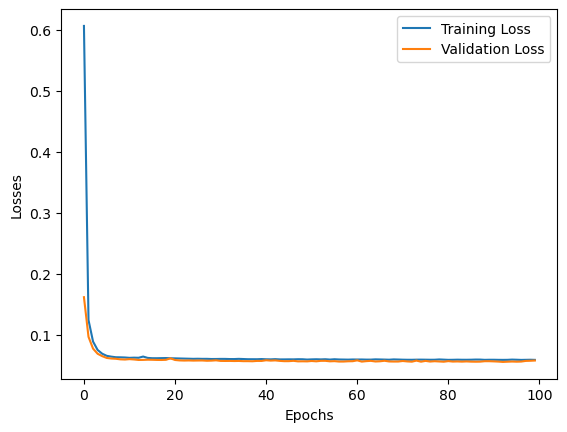

In [16]:
import matplotlib.pyplot as plt 
loss_df = pd.DataFrame({"Training Loss":train_losses,"Validation Loss":validation_losses})
plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()
plt.show()

In [17]:
#loding the best model 
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [21]:
#Evaluation

model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor) #output predicts for training
    test_pred = model(X_test_tensor) #output predicts for testing

    train_mse_loss = crietrion(train_pred,y_train_tensor)
    test_mse_loss = crietrion(test_pred,y_test_tensor)

print("Training MSE : ",train_mse_loss.item())
print("Testing MSE : ",test_mse_loss.item())

Training MSE :  0.05875730887055397
Testing MSE :  0.05580040439963341


In [24]:
# Convert predictions back to original scale
test_pred_original = scaler.inverse_transform(test_pred.numpy())
y_test_original = y_test.values.reshape(-1,1)

# Calculate R2 score correctly
from sklearn.metrics import r2_score
print("R² score:", r2_score(y_test_original, test_pred_original))

R² score: 0.942955853204943
